# Evaluate StdElement-Mapper and StdElement-Mapper+Abstract on the Benchmark 

Evaluates the three trained model against 3 baselines on the benchmark. 


In [1]:
import os, re, json, math, gc
from pathlib import Path
import numpy as np, pandas as pd, torch
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

with open("/home/fan1/.openai_key") as f:
    for line in f:
        if "OPENAI_API_KEY" in line:
            os.environ["OPENAI_API_KEY"] = line.split("=", 1)[1].strip().strip('"').strip("'")
print("OPENAI_API_KEY set:", bool(os.environ.get("OPENAI_API_KEY")))

OPENAI_API_KEY set: True


In [2]:
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
assert OPENAI_API_KEY, "export OPENAI_API_KEY first"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BENCHMARK_XLSX = Path("/opt/gpudata/fan1/heal_cde/ncit/benchmarks/HEAL_CDE_Mappings_0619.xlsx")
SDE_JSONL      = Path("/opt/gpudata/fan1/heal_cde/master_cde/master_sde_v2.jsonl")
RESEARCH_FOCUS_TSV = "/opt/gpudata/fan1/heal_cde/victoria_assets/research_focus_out/study_research_focus_compare.tsv"
FOCUS_COLUMN   = "focus_collapsed_raw"
OUT_DIR        = Path("/opt/gpudata/fan1/heal_cde/ncit/experiments/eval_cache"); OUT_DIR.mkdir(parents=True, exist_ok=True)

EXP_ROOT = "/opt/gpudata/fan1/heal_cde/ncit/experiments"

# the released model: LoRA merged into the base, a standalone SentenceTransformer
MERGED_MODEL = "/opt/gpudata/fan1/heal_cde/StdElement-Mapper-500k-merged"
BASE_MODEL_NAME      = "uc-ctds/bge-large-en-v1.5-bio-mapping"
BGE_MODEL_NAME       = "BAAI/bge-large-en-v1.5"
CTDS_BASE_MODEL_NAME = "uc-ctds/bge-large-en-v1.5-bio-mapping"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

ALL_STUDY_SHEETS = ["HDP00895","HDP01476","HDP01340","HDP01498","HDP01495","HDP01329","HDP01011","HDP00933","HDP00429"]
EXCLUDE_SHEETS   = ["HDP01011"]
STUDY_SHEETS     = [s for s in ALL_STUDY_SHEETS if s not in EXCLUDE_SHEETS]

EMBEDDING_WEIGHT, BM25_WEIGHT = 0.5, 0.5
DENSE_TOPK, BM25_TOPK = 300, 200
BM25_K1 = 1.2
TOP_K_VALUES = [1, 5, 10]

# official names
NAME_OURS   = "StdElement-Mapper"
NAME_OURSF  = "StdElement-Mapper+Abstract"
COL_OURS, COL_OURSF = "#757575", "#2e6f31"
COL_CTDS, COL_OPENAI, COL_BGE = "#fdbac4", "#5d248b", "#f9b83e"

# baselines 
BASELINES = [
    dict(key="ctds",   label="CTDS (uc-ctds/bge-large-en-v1.5-bio-mapping)", color=COL_CTDS,   kind="st", name=CTDS_BASE_MODEL_NAME),
    dict(key="openai", label="OpenAI (text-embedding-3-small)",              color=COL_OPENAI, kind="openai"),
    dict(key="bge",    label="BGE (BAAI/bge-large-en-v1.5)",                 color=COL_BGE,    kind="st", name=BGE_MODEL_NAME),
]
print("model:", MERGED_MODEL)
print("baselines:", [b["key"] for b in BASELINES])

model: /opt/gpudata/fan1/heal_cde/StdElement-Mapper-500k-merged
baselines: ['ctds', 'openai', 'bge']


In [3]:
# ---- benchmark rows  ----
def clean(x, empty=""):
    """None/NaN/blank -> empty; otherwise the stripped string."""
    if x is None or (isinstance(x, float) and math.isnan(x)): return empty
    s = str(x).strip(); return s if s else empty
def _scol(s): return s.fillna("").astype(str).str.strip()

FIELDS = ["field_name","field_type","field_title","field_enumLabels",
          "field_constraints","field_description","element_name","element_title"]
frames = []
xls = pd.ExcelFile(BENCHMARK_XLSX)
for sn in STUDY_SHEETS:
    if sn not in xls.sheet_names: print("  WARNING: sheet", sn, "not found"); continue
    df = xls.parse(sn); df["benchmark"] = sn
    for c in FIELDS + ["standardsMappings.id"]:
        if c not in df.columns: df[c] = ""
    frames.append(df)
raw = pd.concat(frames, ignore_index=True)
raw = raw[(_scol(raw["field_name"]) != "") & (_scol(raw["element_name"]) != "")]
query_df = pd.DataFrame({"benchmark": raw["benchmark"].values})
for c in FIELDS: query_df[c] = _scol(raw[c]).values
query_df["standards_id"] = _scol(raw["standardsMappings.id"]).values
assert not (set(EXCLUDE_SHEETS) & set(query_df["benchmark"].unique()))
print("benchmark rows:", len(query_df))

benchmark rows: 684


In [4]:
# ---- query text: figure fields (original names), pipe-joined, empty -> "" ----
def extract_pairs(s):
    s = clean(s)
    if not s: return []
    if s.startswith("{") and ":" in s:
        kvs = re.findall(r"['\"]([^'\"]+)['\"]\s*:\s*['\"]([^'\"]*)['\"]", s)
        if kvs: return [(k.strip(), v.strip()) for k, v in kvs]
    pairs = []
    for p in re.split(r"\s*\|\s*|\s*;\s*", s):
        p = p.strip()
        if not p: continue
        m = re.match(r"^\s*([^=,:]+)\s*[=,:]\s*(.+)$", p)
        pairs.append((m.group(1).strip(), m.group(2).strip()) if m else ("", p))
    return pairs

def render_enum(enum_labels, empty="[NO_VALUE]"):
    pairs = extract_pairs(enum_labels)          #  1=Male; 2=Female (no code -> label only)
    return empty if not pairs else "; ".join(f"{c}={l}" if c else l for c, l in pairs)

fdf = pd.read_csv(RESEARCH_FOCUS_TSV, sep="\t")
study_focus = dict(zip(fdf["hdp_id"].astype(str), fdf[FOCUS_COLUMN].fillna("")))

# query representation. focus=True appends the study's research focus.
def build_query_text(row, focus=False):
    ftitle = clean(row["field_title"])
    text = (f"code: {clean(row['field_name'])} | variable_type: {clean(row['field_type'])} "
            f"| name: {ftitle} | description: {clean(row['field_description']) or ftitle} "
            f"| values: {render_enum(row['field_enumLabels'])}")
    if focus:
        foc = clean(study_focus.get(str(row["benchmark"]), ""))
        if foc: text += f" | research_focus: {foc}"
    return text

query_df["query_text"]       = query_df.apply(lambda r: build_query_text(r, focus=False), axis=1)
query_df["query_text_focus"] = query_df.apply(lambda r: build_query_text(r, focus=True),  axis=1)
print("plain:", query_df["query_text"].iloc[0][:170])
print("focus:", query_df["query_text_focus"].iloc[0][:170])

plain: code: dob | variable_type: date | name: Date of birth | description: Contact Information: Date of birth | values: [NO_VALUE]
focus: code: dob | variable_type: date | name: Date of birth | description: Contact Information: Date of birth | values: [NO_VALUE] | research_focus: Pain, Quality of Life, Slee


In [5]:
# ---- gold resolve ----
full_objs = []
with open(SDE_JSONL) as f:
    for line in f:
        if line.strip(): full_objs.append(json.loads(line))
seen=set(); dd=[]
for o in full_objs:
    sid=clean(o.get("sde_id"))
    if sid and sid in seen: continue
    seen.add(sid); dd.append(o)
full_objs = dd
print("FULL target pool (no HEAL filter):", len(full_objs))

INSTITUTE_CODES = {"GRDR","LOINC","NCI","NEI","NHLBI","NICHD","NIDA","NINDS","NINR","NLM","ONC","QST","TBI","TEST"}
def clean_domain(d):
    d = clean(d); return "" if (d.lower()=="nan" or d in INSTITUTE_CODES) else d

# target representation. focus=True appends the parent domain.
def build_target_text(o, focus=False):
    text = (f"sde_id: {clean(o.get('sde_id'))} | name: {clean(o.get('sde_name'))} "
            f"| type: {clean(o.get('sde_data_type'))} | description: {clean(o.get('sde_description'))} "
            f"| values: {clean(o.get('sde_permissible_values'), '[NO_VALUES]')} "
            f"| value_description: {clean(o.get('sde_pv_description'), '[NO_VALUE_DESCRIPTION]')} "
            f"| additional_info: {clean(o.get('sde_additional_info'), '[NO_ADDITIONAL_INFO]')}")
    if focus:
        dom = clean_domain(o.get("sde_parent_domain"))
        if dom: text += f" | research_focus: {dom}"
    return text

target_texts       = [build_target_text(o, focus=False) for o in full_objs]
target_texts_focus = [build_target_text(o, focus=True)  for o in full_objs]

def norm_id(x): return re.sub(r"\s+","",clean(x)).lower()
def norm_nm(x): return re.sub(r"\s+"," ", re.sub(r"[^a-z0-9]+"," ", clean(x).lower())).strip()
id2i={}; nm2i={}; nid2i={}; nnm2i={}
for i, o in enumerate(full_objs):
    sid=clean(o.get("sde_id")); snm=clean(o.get("sde_name"))
    if sid: id2i.setdefault(sid,i); nid2i.setdefault(norm_id(sid),i)
    if snm: nm2i.setdefault(snm,i); nnm2i.setdefault(norm_nm(snm),i)
def resolve_gold(row):
    # 4-level match: id exact -> name exact -> id normalized -> name normalized
    candidates = [clean(row["element_name"]), clean(row["element_title"]), clean(row["standards_id"])]
    for table, norm in [(id2i, None), (nm2i, None), (nid2i, norm_id), (nnm2i, norm_nm)]:
        for c in candidates:
            key = c if norm is None else norm(c)
            if c and key in table: return [table[key]]
    return []
query_df["gold_indices"] = query_df.apply(resolve_gold, axis=1)
before=len(query_df)
eval_df = query_df[query_df["gold_indices"].apply(len)>0].reset_index(drop=True)
N = len(eval_df)
gold_sets = [set(map(int,g)) for g in eval_df["gold_indices"]]
query_texts       = eval_df["query_text"].tolist()
query_texts_focus = eval_df["query_text_focus"].tolist()
print(f"resolved gold: {N} / {before} rows kept ({before-N} dropped, gold not in pool)")

FULL target pool (no HEAL filter): 56300
resolved gold: 634 / 684 rows kept (50 dropped, gold not in pool)


In [9]:
# ---- retrieval + fusion helpers ----
from rank_bm25 import BM25Okapi
from sklearn.preprocessing import minmax_scale
from sentence_transformers.util import semantic_search
def tokenize(s): return re.findall(r"[a-z0-9]+", clean(s).lower())
def bm25_topk(bm, query, k):
    sc = bm.get_scores(tokenize(query)); idx = np.argsort(sc)[::-1][:k]; return idx, sc[idx]
def dense_topk(q_emb, t_emb):
    hits = semantic_search(q_emb, t_emb, top_k=DENSE_TOPK)
    return [(np.array([h["corpus_id"] for h in hs]), np.array([h["score"] for h in hs])) for hs in hits]
def norm_series(idx, sc, w):
    return pd.Series(minmax_scale(sc)*w if len(sc) else [], index=idx, dtype=float)
def hybrid_hits(dense, bm25_cache):
    hits={k:0 for k in TOP_K_VALUES}
    for i in range(N):
        d=norm_series(*dense[i], EMBEDDING_WEIGHT); b=norm_series(*bm25_cache[i], BM25_WEIGHT)
        fused=d.add(b, fill_value=0.0).sort_values(ascending=False)
        rank=next((r for r,ci in enumerate(fused.index,1) if ci in gold_sets[i]), None)
        if rank:
            for k in TOP_K_VALUES:
                if rank<=k: hits[k]+=1
    return hits
def encode(model, texts):
    return model.encode(texts, batch_size=256, normalize_embeddings=True, convert_to_tensor=True, show_progress_bar=False)
def embed_openai(texts, desc="openai"):
    from openai import OpenAI
    client=OpenAI(api_key=OPENAI_API_KEY); out=[]
    clean=[t if isinstance(t,str) else "" for t in texts]
    for s in tqdm(range(0,len(clean),256), desc=desc):
        out.extend(d.embedding for d in client.embeddings.create(model=OPENAI_EMBEDDING_MODEL, input=clean[s:s+256]).data)
    return np.asarray(out, np.float32)

In [7]:
# ---- BM25 ----
bm_plain = BM25Okapi([tokenize(t) for t in target_texts],       k1=BM25_K1)
bm_focus = BM25Okapi([tokenize(t) for t in target_texts_focus], k1=BM25_K1)
bm25_plain = [bm25_topk(bm_plain, q, BM25_TOPK) for q in tqdm(query_texts,       desc="bm25 plain")]
bm25_focus = [bm25_topk(bm_focus, q, BM25_TOPK) for q in tqdm(query_texts_focus, desc="bm25 focus")]
print("BM25 caches built")

bm25 plain:   0%|          | 0/634 [00:00<?, ?it/s]

bm25 focus:   0%|          | 0/634 [00:00<?, ?it/s]

BM25 caches built


In [10]:
# ---- score the merged model + 3 baselines into RESULTS[label][k] ----
RESULTS = {}

def score_st(model, focus):
    q  = query_texts_focus  if focus else query_texts
    t  = target_texts_focus if focus else target_texts
    bm = bm25_focus         if focus else bm25_plain
    return hybrid_hits(dense_topk(encode(model, q), encode(model, t)), bm)

def log(label, hits):
    RESULTS[label] = hits
    print(f"{label:<45} " + "  ".join(f"T{k}={hits[k]}" for k in TOP_K_VALUES))

# baselines (no research focus)
for spec in BASELINES:
    if spec["kind"] == "st":
        m = SentenceTransformer(spec["name"], device=str(device))
        hits = score_st(m, focus=False)
        del m; gc.collect(); torch.cuda.empty_cache()
    else:  # openai
        qe = torch.as_tensor(embed_openai(query_texts, "openai q"))
        te = torch.as_tensor(embed_openai(target_texts, "openai t"))
        hits = hybrid_hits(dense_topk(qe, te), bm25_plain)
    log(spec["label"], hits)

# the merged model: plain + with research focus (same weights, different input)
m = SentenceTransformer(MERGED_MODEL, device=str(device))
log(NAME_OURS,  score_st(m, focus=False))
log(NAME_OURSF, score_st(m, focus=True))
del m; gc.collect(); torch.cuda.empty_cache()
print("done")

CTDS (uc-ctds/bge-large-en-v1.5-bio-mapping)  T1=421  T5=549  T10=594


openai q:   0%|          | 0/3 [00:00<?, ?it/s]

openai t:   0%|          | 0/220 [00:00<?, ?it/s]

OpenAI (text-embedding-3-small)               T1=411  T5=533  T10=583
BGE (BAAI/bge-large-en-v1.5)                  T1=390  T5=515  T10=581
StdElement-Mapper                             T1=427  T5=573  T10=608
StdElement-Mapper+Abstract                    T1=428  T5=588  T10=615
done


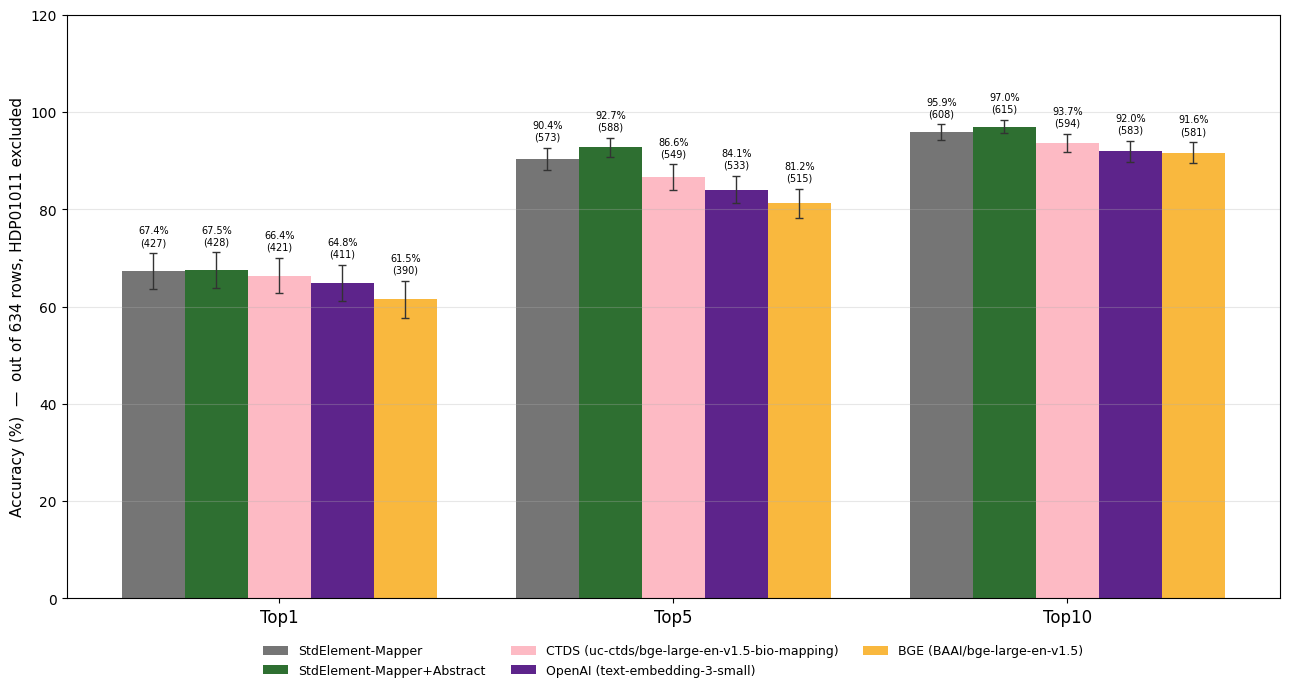

saved -> /opt/gpudata/fan1/heal_cde/ncit/experiments/eval_cache/benchmark_5bar_merged_500k.png


In [11]:
# ---- Accuracy figure: 5 bars, Top-1/5/10 ----
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

def wilson_half(k, n):
    """Half-width (percentage points) of the 95% Wilson score interval for k/n."""
    if n == 0: return 0.0
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    return (hi - lo) / 2 * 100

ks = TOP_K_VALUES; x = np.arange(len(ks))
BASE_LABELS = [b["label"] for b in BASELINES]
BASE_COLORS = {BASELINES[0]["label"]: COL_CTDS, BASELINES[1]["label"]: COL_OPENAI, BASELINES[2]["label"]: COL_BGE}

bars = [(NAME_OURS, COL_OURS, RESULTS[NAME_OURS]),
        (NAME_OURSF, COL_OURSF, RESULTS[NAME_OURSF])] + \
       [(bl, BASE_COLORS[bl], RESULTS[bl]) for bl in BASE_LABELS]
w = 0.8 / len(bars)
fig, ax = plt.subplots(figsize=(13, 7))
for i, (label, color, h) in enumerate(bars):
    pct = [h[k]/N*100 for k in ks]; err = [wilson_half(h[k], N) for k in ks]
    off = (i - (len(bars)-1)/2) * w
    bb = ax.bar(x+off, pct, w, label=label, color=color, yerr=err, capsize=3, error_kw=dict(lw=1, ecolor="#333"))
    for b, p, e, k in zip(bb, pct, err, ks):
        ax.text(b.get_x()+b.get_width()/2, p+e+1.2, f"{p:.1f}%\n({h[k]})", ha="center", va="bottom", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels([f"Top{k}" for k in ks], fontsize=12)
ax.set_ylabel(f"Accuracy (%)  \u2014  out of {N} rows, HDP01011 excluded", fontsize=11)
ax.set_ylim(0, 120); ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper center", bbox_to_anchor=(0.5,-0.06), ncol=3, fontsize=9, frameon=False)
plt.tight_layout()
p = OUT_DIR/"benchmark_5bar_merged_500k.png"; plt.savefig(p, dpi=200, bbox_inches="tight"); plt.show()
print("saved ->", p)